# Data inspection

In [1]:
import cv2
import json
import matplotlib.pyplot as plt
import numpy as np
import os

Load sample(s) by taking both the image as the keypoints

In [15]:
# Paths to your sample files (Replace with actual filenames from your run)
image_path = 'output_keypoints/rgb/Angled_Street_ClearNoon_mkz_2020_BWD_2659.png'
json_path = 'output_keypoints/keypoints/Angled_Street_ClearNoon_mkz_2020_BWD_2659.json'

# Load the image
# OpenCV loads images in BGR format, but Matplotlib expects RGB, so we convert it
img = cv2.imread(image_path)
if img is None:
    print(f"Error: Could not load image at {image_path}")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load the keypoints
if not os.path.exists(json_path):
    print(f"Error: Could not find JSON at {json_path}")
else:
    with open(json_path, 'r') as f:
        keypoints = json.load(f)

    print(f"Loaded {len(keypoints)} keypoints.")

Loaded 8 keypoints.


Draw the new image showing the keypoints visually

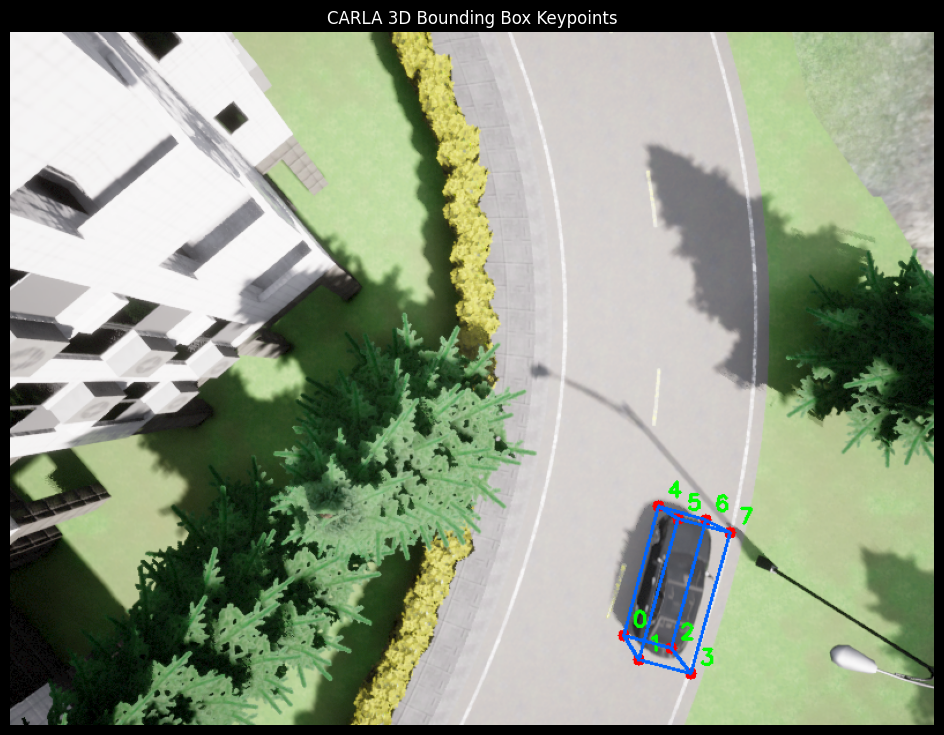

In [16]:
# Make a copy of the image so we don't draw on the original data
vis_img = img.copy()

# 1. Draw the dots and index numbers
for idx, pt in enumerate(keypoints):
    x, y = int(pt[0]), int(pt[1])

    # Draw a solid red circle at the keypoint
    cv2.circle(vis_img, (x, y), radius=5, color=(255, 0, 0), thickness=-1)

    # Draw the index number slightly offset in bright green
    cv2.putText(vis_img, str(idx), (x + 8, y - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# 2. Connect the dots (Wireframe)
# CARLA typically returns bounding box vertices in this order:
# 0-3 are the bottom plane, 4-7 are the top plane.
if len(keypoints) == 8:
    edges = [
        # Bottom plane edges
        (0, 1), (1, 3), (3, 2), (2, 0),
        # Top plane edges
        (4, 5), (5, 7), (7, 6), (6, 4),
        # Vertical pillars connecting bottom to top
        (0, 4), (1, 5), (2, 6), (3, 7)
    ]

    for start_idx, end_idx in edges:
        # Get coordinates
        pt1 = (int(keypoints[start_idx][0]), int(keypoints[start_idx][1]))
        pt2 = (int(keypoints[end_idx][0]), int(keypoints[end_idx][1]))

        # Draw a semi-transparent blue line
        cv2.line(vis_img, pt1, pt2, color=(0, 100, 255), thickness=2)

# 3. Display the result inline in Jupyter
plt.figure(figsize=(12, 9))
plt.imshow(vis_img)
plt.axis('off') # Hide the axis ticks
plt.title('CARLA 3D Bounding Box Keypoints')
plt.show()